 Install & Import Libraries

In [1]:
# ================================================
# SAUDI RETAIL SALES FORECASTING
# Notebook 4: Prophet Forecasting
# ================================================

# Install Prophet
!pip install prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print("✅ All libraries ready!")

✅ All libraries ready!


In [2]:
# Load clean data
df = pd.read_csv("/content/saudi_sales_clean.csv",
                  parse_dates=['date'])

# Prophet requires exactly 2 columns: ds (date) and y (value)
df_prophet = df[['date', 'sales_thousand_sar']].copy()
df_prophet.columns = ['ds', 'y']

# Convert to Billion SAR for easier reading
df_prophet['y'] = df_prophet['y'] / 1000000

print("✅ Data ready for Prophet!")
print(f"📊 Rows: {df_prophet.shape[0]}")
print(f"📅 From: {df_prophet['ds'].min().date()}")
print(f"📅 To:   {df_prophet['ds'].max().date()}")
print(f"📈 Min sales: {df_prophet['y'].min():.1f}B SAR")
print(f"📈 Max sales: {df_prophet['y'].max():.1f}B SAR")
df_prophet.head()

✅ Data ready for Prophet!
📊 Rows: 135
📅 From: 2015-01-01
📅 To:   2026-03-01
📈 Min sales: 12.5B SAR
📈 Max sales: 66.1B SAR


,ds,y
0,2015-01-01,14.226961
1,2015-02-01,15.352751
2,2015-03-01,15.401083
3,2015-04-01,13.566170
4,2015-05-01,15.145620


In [3]:
# ================================================
# BUILD PROPHET MODEL
# ================================================

model = Prophet(
    yearly_seasonality=True,    # Capture yearly patterns
    weekly_seasonality=False,   # Monthly data - no weekly
    daily_seasonality=False,    # Monthly data - no daily
    seasonality_mode='multiplicative',  # Better for growing trends
    changepoint_prior_scale=0.1,        # Flexibility of trend
    seasonality_prior_scale=10,         # Strength of seasonality
    interval_width=0.95                 # 95% confidence interval
)

# Add COVID-19 as a special event (shock to the model)
model.add_country_holidays(country_name='SA')  # Saudi holidays

# Fit the model
model.fit(df_prophet)

print("✅ Prophet model trained successfully!")
print("📊 Model learned from 11 years of data (2015-2026)")

✅ Prophet model trained successfully!
📊 Model learned from 11 years of data (2015-2026)


In [4]:
# ================================================
# FORECAST: Predict 24 months into the future
# ================================================

# Create future dates — 24 months ahead
future = model.make_future_dataframe(periods=24, freq='MS')

# Generate forecast
forecast = model.predict(future)

# Clean results
forecast_clean = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_clean.columns = ['date', 'predicted', 'lower_bound', 'upper_bound']

# Show future predictions only
future_only = forecast_clean[forecast_clean['date'] > df_prophet['ds'].max()]

print("=" * 60)
print("📊 FORECAST: Next 24 Months")
print("=" * 60)
print(f"{'Date':<15} {'Predicted':>12} {'Low':>10} {'High':>10}")
print("-" * 50)
for _, row in future_only.iterrows():
    print(f"{str(row['date'].date()):<15} "
          f"{row['predicted']:>10.1f}B  "
          f"{row['lower_bound']:>8.1f}B  "
          f"{row['upper_bound']:>8.1f}B")

📊 FORECAST: Next 24 Months
Date               Predicted        Low       High
--------------------------------------------------
2026-04-01            63.3B      59.4B      67.0B
2026-05-01            64.1B      60.4B      67.8B
2026-06-01            62.0B      58.0B      66.0B
2026-07-01            62.0B      58.2B      65.7B
2026-08-01            66.7B      62.9B      70.6B
2026-09-01            63.1B      59.3B      66.9B
2026-10-01            63.8B      60.0B      67.9B
2026-11-01            64.1B      60.2B      68.1B
2026-12-01            67.4B      63.2B      71.2B
2027-01-01            66.2B      62.1B      70.0B
2027-02-01            62.2B      58.5B      66.2B
2027-03-01            72.0B      68.0B      76.1B
2027-04-01            69.6B      65.7B      73.6B
2027-05-01            67.9B      64.0B      72.3B
2027-06-01            65.1B      60.9B      69.0B
2027-07-01            65.5B      61.0B      69.9B
2027-08-01            71.1B      66.9B      75.8B
2027-09-01           

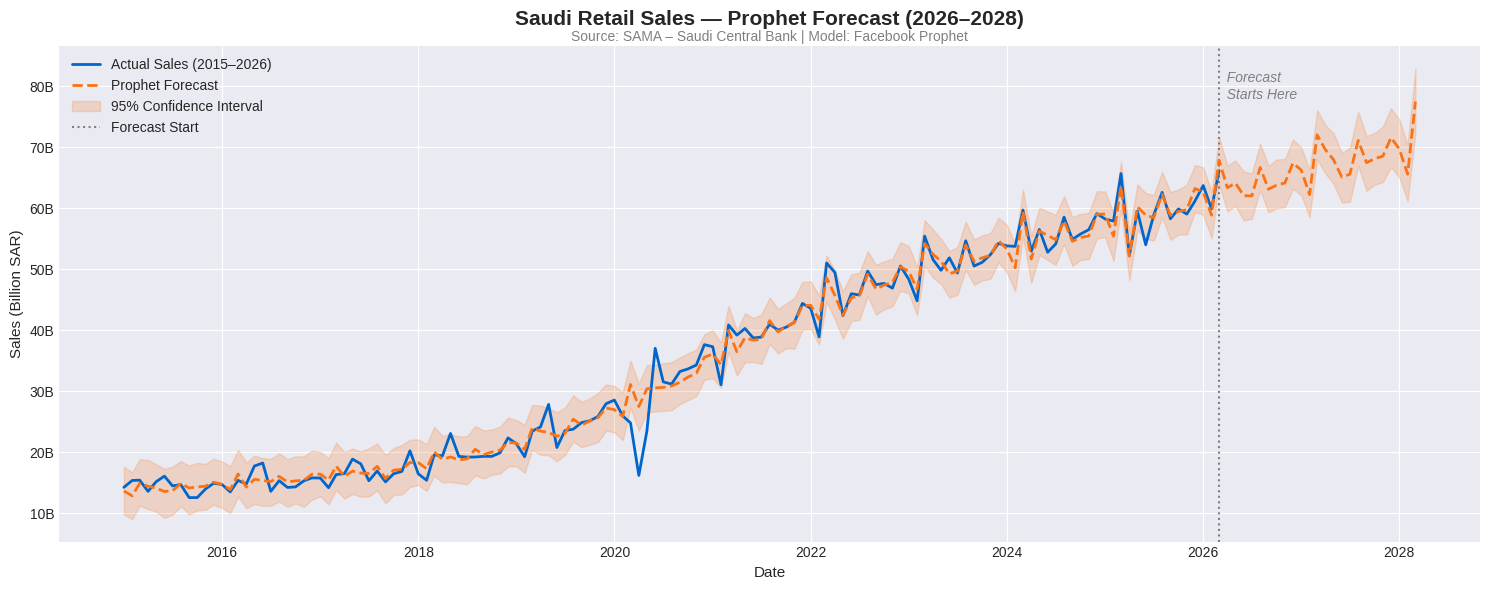

✅ Chart 6 saved!


In [5]:
# ================================================
# CHART 6: Full Forecast Visualization
# ================================================

fig, ax = plt.subplots(figsize=(15, 6))

# Historical data
ax.plot(df_prophet['ds'], df_prophet['y'],
        color='#0066CC', linewidth=2,
        label='Actual Sales (2015–2026)', zorder=3)

# Predicted line
ax.plot(forecast_clean['date'], forecast_clean['predicted'],
        color='#f97316', linewidth=2, linestyle='--',
        label='Prophet Forecast', zorder=3)

# Confidence interval
ax.fill_between(forecast_clean['date'],
                forecast_clean['lower_bound'],
                forecast_clean['upper_bound'],
                alpha=0.2, color='#f97316',
                label='95% Confidence Interval')

# Mark where forecast starts
split_date = df_prophet['ds'].max()
ax.axvline(x=split_date, color='gray', linewidth=1.5,
           linestyle=':', label='Forecast Start')
ax.text(split_date, ax.get_ylim()[1] * 0.9,
        '  Forecast\n  Starts Here',
        color='gray', fontsize=10, fontstyle='italic')

ax.set_title('Saudi Retail Sales — Prophet Forecast (2026–2028)',
             fontsize=15, fontweight='bold', pad=15)
ax.text(0.5, 1.01, 'Source: SAMA – Saudi Central Bank | Model: Facebook Prophet',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Sales (Billion SAR)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fB'))
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('/content/chart6_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

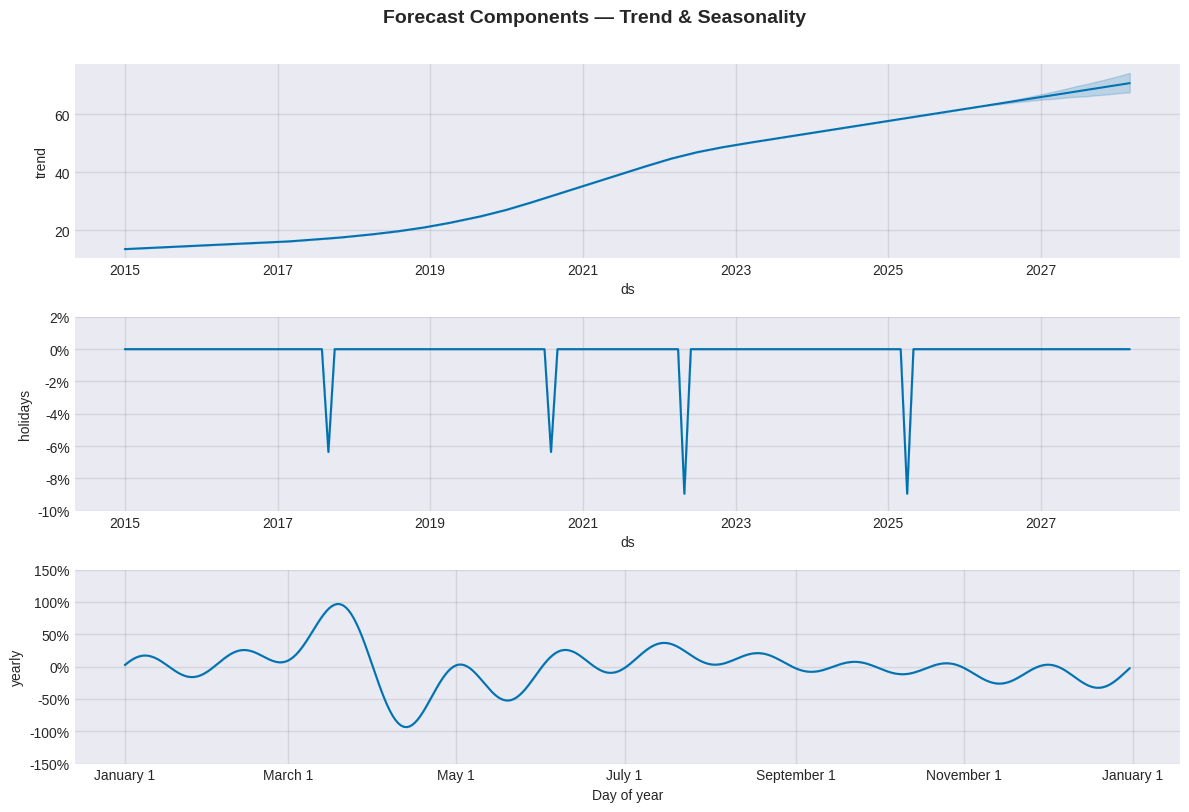

✅ Chart 7 saved!

📖 How to read this chart:
   Top panel    → Overall upward trend over time
   Bottom panel → Which months are naturally high/low


In [12]:
# ================================================
# CHART 7: What drives the forecast?
# ================================================

fig = model.plot_components(forecast)
fig.set_size_inches(12, 8)
fig.suptitle('Forecast Components — Trend & Seasonality',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('/content/chart7_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")
print("\n📖 How to read this chart:")
print("   Top panel    → Overall upward trend over time")
print("   Bottom panel → Which months are naturally high/low")

In [7]:
# ================================================
# SAVE ALL FORECAST FILES
# ================================================

# Save forecast CSV
forecast_clean.to_csv('/content/forecast_results.csv', index=False)
future_only.to_csv('/content/forecast_future_only.csv', index=False)

print("✅ Notebook 4 COMPLETE!")
print("\n📁 New files saved:")
print("   → forecast_results.csv      (full history + forecast)")
print("   → forecast_future_only.csv  (next 24 months only)")
print("   → chart6_forecast.png")
print("   → chart7_components.png")
print("\n⬇️  Download all files from Colab!")
print("\n🎯 Progress:")
print("   ✅ Notebook 1 → Data Cleaning")
print("   ✅ Notebook 2 → SQL Analysis")
print("   ✅ Notebook 3 → Visualization")
print("   ✅ Notebook 4 → Forecasting")
print("   ⏳ Power BI   → Dashboard (FINAL STEP!)")

✅ Notebook 4 COMPLETE!

📁 New files saved:
   → forecast_results.csv      (full history + forecast)
   → forecast_future_only.csv  (next 24 months only)
   → chart6_forecast.png
   → chart7_components.png

⬇️  Download all files from Colab!

🎯 Progress:
   ✅ Notebook 1 → Data Cleaning
   ✅ Notebook 2 → SQL Analysis
   ✅ Notebook 3 → Visualization
   ✅ Notebook 4 → Forecasting
   ⏳ Power BI   → Dashboard (FINAL STEP!)
